# PAE Heatmaps and Structural Metrics — LRBA × STX7 and LRBA × STX12

Reads every sample in the `afx_pred/lrba_stx{7,12}_{0,1,2}/` directories and plots the
Predicted Aligned Error (PAE) matrix and per-residue metrics for each pair.

| Chain | Identity | Residues |
|-------|----------|----------|
| A | LRBA | 863 |
| B | STX7 or STX12 | 261 / 276 |
| C | ligand (excluded) | 27 tokens |

Data source: `N:\08_NK_structure_prediction\data\LRBAandSNARE\assembled_complex`

In [1]:
print("test")

test


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
AFX_ROOT        = Path(r"N:\08_NK_structure_prediction\data\LRBAandSNARE\afx_pred")
ASSEMBLED_ROOT  = Path(r"N:\08_NK_structure_prediction\data\LRBAandSNARE\assembled_complex")

# Run directories per protein (each contains seed-1_sample-{0-4})
STX7_RUN_DIRS  = [AFX_ROOT / f"lrba_stx7_{i}"  for i in range(3)]
STX12_RUN_DIRS = [AFX_ROOT / f"lrba_stx12_{i}" for i in range(3)]

# Assembled complex PDB and confidences
PAIRS_DIR    = ASSEMBLED_ROOT / "pairs"
PLDDT_DIR    = ASSEMBLED_ROOT / "plddt"

# Chain → gene name
CHAIN_GENE_STX7  = {"A": "LRBA", "B": "STX7",  "C": "ligand"}
CHAIN_GENE_STX12 = {"A": "LRBA", "B": "STX12", "C": "ligand"}
LIGAND_CHAINS    = {"C"}

INTERFACE_PAE_CUTOFF = 12.0

FIGURE_DIR = (
    Path(r"N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result")
    / "lrba_stx7_stx12_metrics"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output → {FIGURE_DIR}")

Figure output → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\lrba_stx7_stx12_metrics


In [4]:
# ── Nature figure style ───────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "legend.title_fontsize": 6,
    "legend.frameon":     False,
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "lines.linewidth":    0.75,
    "patch.linewidth":    0.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

NC1 = 89  / 25.4
NC2 = 183 / 25.4

WONG = ["#0072B2", "#E69F00", "#009E73", "#CC79A7",
        "#56B4E9", "#D55E00", "#F0E442", "#000000"]

def _panel_label(idx):
    q, r = divmod(idx, 26)
    base = chr(ord('a') + r)
    return (chr(ord('a') + q - 1) + base) if q else base

def save_fig(fig, name):
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg")
    print(f"Saved → {path}")

In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────
_pdb_parser = PDBParser(QUIET=True)


def load_confidences(path):
    """Return (token_chain_ids, token_res_ids, pae_array, atom_plddts)."""
    with open(path) as fh:
        d = json.load(fh)
    return (
        np.array(d["token_chain_ids"]),
        np.array(d["token_res_ids"], dtype=int),
        np.array(d["pae"]),
        np.array(d.get("atom_plddts", [])),
    )


def load_summary(path):
    with open(path) as fh:
        return json.load(fh)


def get_ca_plddt(pdb_path):
    """Return per-residue pLDDT (Cα B-factor), chain IDs, and residue numbers."""
    structure = _pdb_parser.get_structure("s", str(pdb_path))
    plddt, chains, res_ids = [], [], []
    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] != " ":
                    continue
                if "CA" not in res:
                    continue
                ca = res["CA"]
                plddt.append(ca.get_bfactor())
                chains.append(chain.id)
                res_ids.append(res.id[1])
    return np.array(plddt), np.array(chains), np.array(res_ids, dtype=int)


def chain_boundaries(token_chains):
    """Return boundary indices where chain changes."""
    bounds = [0]
    for i in range(1, len(token_chains)):
        if token_chains[i] != token_chains[i - 1]:
            bounds.append(i)
    bounds.append(len(token_chains))
    return bounds


def compute_iptm(pae, token_chain_ids, cutoff=INTERFACE_PAE_CUTOFF):
    """Compute interface-TM score from a PAE matrix (inter-chain pairs with PAE < cutoff)."""
    n  = len(token_chain_ids)
    d0 = max(1.24 * max(n - 15, 1) ** (1 / 3) - 1.8, 0.1)
    inter  = token_chain_ids[:, None] != token_chain_ids[None, :]
    intf   = inter & ((pae < cutoff) | (pae.T < cutoff))
    n_intf = int(intf.sum())
    if n_intf == 0:
        return np.nan
    tm = 1.0 / (1.0 + (pae / d0) ** 2)
    return float((tm * intf).sum() / n_intf)


def filter_ligand(tc, pae, exclude=None):
    """Remove ligand tokens from tc and slice the corresponding PAE rows/cols."""
    if exclude is None:
        exclude = LIGAND_CHAINS
    mask = np.array([c not in exclude for c in tc])
    return tc[mask], pae[np.ix_(mask, mask)]

In [6]:
# ── Load samples from multiple run directories ────────────────────────────────

def load_all_samples(run_dirs, prefix):
    """
    Scan run_dirs for seed-*/sample-* subdirectories.
    Returns a list of dicts with keys: label, run, tc, pae, summary, rank_score.
    Deduplicates by (ranking_score, PAE-hash) to avoid counting identical runs twice.
    """
    samples = []
    seen_scores = set()

    for run_dir in run_dirs:
        run_dir = Path(run_dir)
        if not run_dir.exists():
            print(f"[SKIP] {run_dir} not found")
            continue

        # Load ranking scores for this run
        rank_map = {}
        ranking_csv = run_dir / "ranking_scores.csv"
        if ranking_csv.exists():
            rdf = pd.read_csv(ranking_csv)
            for _, row in rdf.iterrows():
                lbl = f"seed-{int(row['seed'])}_sample-{int(row['sample'])}"
                rank_map[lbl] = row["ranking_score"]

        for subdir in sorted(run_dir.iterdir()):
            if not subdir.is_dir():
                continue
            conf = subdir / "confidences.json"
            summ = subdir / "summary_confidences.json"
            if not conf.exists():
                continue

            label     = subdir.name
            run_name  = run_dir.name
            rank_score = rank_map.get(label, np.nan)

            # Deduplicate runs with identical ranking scores
            key = round(rank_score, 8) if not np.isnan(rank_score) else id(subdir)
            if key in seen_scores:
                continue
            seen_scores.add(key)

            tc, tr, pae, plddts = load_confidences(conf)
            s = load_summary(summ) if summ.exists() else {}
            samples.append(dict(
                label      = f"{run_name}/{label}",
                tc         = tc,
                tr         = tr,
                pae        = pae,
                plddts     = plddts,
                summary    = s,
                rank_score = rank_score,
            ))

    samples.sort(key=lambda s: s["rank_score"] if not np.isnan(s["rank_score"]) else -1, reverse=True)
    print(f"\n{prefix}: {len(samples)} unique samples loaded")
    for s in samples:
        iptm = s["summary"].get("iptm", np.nan)
        print(f"  {s['label']:40s}  rank={s['rank_score']:.4f}  ipTM={iptm}")
    return samples


samples_stx7  = load_all_samples(STX7_RUN_DIRS,  prefix="LRBA×STX7")
samples_stx12 = load_all_samples(STX12_RUN_DIRS, prefix="LRBA×STX12")


LRBA×STX7: 10 unique samples loaded
  lrba_stx7_1/seed-1_sample-2               rank=0.4253  ipTM=0.31
  lrba_stx7_1/seed-1_sample-4               rank=0.4011  ipTM=0.31
  lrba_stx7_1/seed-1_sample-3               rank=0.3961  ipTM=0.29
  lrba_stx7_0/seed-1_sample-0               rank=0.3918  ipTM=0.27
  lrba_stx7_0/seed-1_sample-2               rank=0.3849  ipTM=0.27
  lrba_stx7_1/seed-1_sample-0               rank=0.3794  ipTM=0.25
  lrba_stx7_0/seed-1_sample-1               rank=0.3693  ipTM=0.25
  lrba_stx7_0/seed-1_sample-4               rank=0.3633  ipTM=0.26
  lrba_stx7_1/seed-1_sample-1               rank=0.3456  ipTM=0.23
  lrba_stx7_0/seed-1_sample-3               rank=0.3446  ipTM=0.24

LRBA×STX12: 5 unique samples loaded
  lrba_stx12_0/seed-1_sample-1              rank=0.4888  ipTM=0.4
  lrba_stx12_0/seed-1_sample-2              rank=0.4769  ipTM=0.37
  lrba_stx12_0/seed-1_sample-4              rank=0.4745  ipTM=0.36
  lrba_stx12_0/seed-1_sample-0              rank=0.4738 

## Figure 2 — Best-ranked PAE Heatmaps: LRBA × STX7 and LRBA × STX12

In [ ]:
# ── Figure 2: Best-ranked PAE heatmaps — LRBA × STX7 and LRBA × STX12 (side by side) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(NC2, NC2 * 0.55), constrained_layout=True)

for ax, (samples, chain_gene, pair_name), panel in zip(
    axes,
    [
        (samples_stx7,  CHAIN_GENE_STX7,  "LRBA × STX7"),
        (samples_stx12, CHAIN_GENE_STX12, "LRBA × STX12"),
    ],
    ["a", "b"],
):
    best = max(samples, key=lambda s: s["rank_score"] if not np.isnan(s["rank_score"]) else -1)
    pae  = best["pae"]
    tc   = best["tc"]
    tc, pae = filter_ligand(tc, pae)
    N      = len(tc)
    bounds = chain_boundaries(tc)

    im = ax.imshow(
        pae, cmap="RdYlGn_r", vmin=0, vmax=30,
        aspect="equal", interpolation="nearest", rasterized=True,
    )

    for b in bounds[1:-1]:
        ax.axhline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)
        ax.axvline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)

    unique_chains = list(dict.fromkeys(tc))
    offset = N * 0.04
    for k, c in enumerate(unique_chains):
        mid  = (bounds[k] + bounds[k + 1]) / 2
        name = chain_gene.get(c, c)
        ax.text(mid, -offset, name, ha="center", va="center",
                fontsize=6.5, rotation=30, clip_on=False, fontweight="bold")
        ax.text(-offset, mid, name, ha="center", va="center",
                fontsize=6.5, rotation=90, clip_on=False, fontweight="bold")

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    iptm_val = best["summary"].get("iptm", np.nan)
    iptm_str = f"{iptm_val:.3f}" if isinstance(iptm_val, float) and not np.isnan(iptm_val) else str(iptm_val)
    ax.set_title(
        f"{pair_name}\nipTM = {iptm_str}  |  rank = {best['rank_score']:.4f}",
        pad=6, fontsize=7,
    )

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, shrink=0.88)
    cb.set_label("PAE (Å)", labelpad=2, fontsize=6)
    cb.ax.tick_params(labelsize=5, width=0.4, length=2)
    cb.outline.set_linewidth(0.4)

    ax.text(-0.08, 1.06, panel, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top")

fig.suptitle("Best-ranked PAE heatmaps — LRBA × STX7 vs. LRBA × STX12", fontsize=8)
save_fig(fig, "pae_best_side_by_side")
plt.show()

**Fig. 2 | PAE heatmaps of the highest-ranked AlphaFold models for LRBA–STX7 and LRBA–STX12.**
**(a)** LRBA–STX7, **(b)** LRBA–STX12, each showing the sample with the highest AlphaFold ranking score. The ligand chain is excluded. The colour scale (0–30 Å, RdYlGn) is shared between panels. Low off-diagonal PAE values in the inter-chain quadrants indicate high confidence in the predicted relative orientation of the two proteins. Panel titles report the ipTM score and AlphaFold ranking score for each best model.

## Figure 7 — Per-residue Mean Inter-chain PAE (Assembled Complex)

In [14]:
# ── Load assembled complex confidences (single best-assembly files) ───────────
assembled_pairs = {
    "LRBA×STX7" : {
        "conf"     : PLDDT_DIR / "lrba_stx7_0_AB_confidences.json",
        "pdb"      : PAIRS_DIR / "lrba_stx7_0_AB" / "lrba_stx7_0_AB_A-lrba_stx7_0_AB_B.pdb",
        "chain_gene": CHAIN_GENE_STX7,
    },
    "LRBA×STX12": {
        "conf"     : PLDDT_DIR / "lrba_stx12_0_AC_confidences.json",
        "pdb"      : PAIRS_DIR / "lrba_stx12_0_AC" / "lrba_stx12_0_AC_A-lrba_stx12_0_AC_C.pdb",
        "chain_gene": CHAIN_GENE_STX12,
    },
}

for pair_name, meta in assembled_pairs.items():
    tc, tr, pae, _ = load_confidences(meta["conf"])
    plddt, chain_ids, res_ids = get_ca_plddt(meta["pdb"])

    inter_mask     = tc[:, None] != tc[None, :]
    mean_inter_pae = float(pae[inter_mask].mean()) if inter_mask.any() else np.nan
    iptm_val       = compute_iptm(pae, tc)
    mean_plddt     = float(plddt.mean())

    meta["tc"]             = tc
    meta["tr"]             = tr
    meta["pae"]            = pae
    meta["plddt"]          = plddt
    meta["chain_ids_pdb"]  = chain_ids
    meta["res_ids_pdb"]    = res_ids
    meta["iptm"]           = iptm_val
    meta["mean_plddt"]     = mean_plddt
    meta["mean_inter_pae"] = mean_inter_pae

    iptm_str = f"{iptm_val:.4f}" if not np.isnan(iptm_val) else "n/a"
    print(f"{pair_name:12s}  n_tokens={len(tc)}  ipTM={iptm_str}  "
          f"mean_pLDDT={mean_plddt:.1f}  mean_inter_PAE={mean_inter_pae:.1f} Å")

LRBA×STX7     n_tokens=1151  ipTM=0.3884  mean_pLDDT=80.8  mean_inter_PAE=28.2 Å
LRBA×STX12    n_tokens=1166  ipTM=0.3845  mean_pLDDT=81.1  mean_inter_PAE=25.8 Å


Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\lrba_stx7_stx12_metrics\inter_chain_pae_per_residue.svg


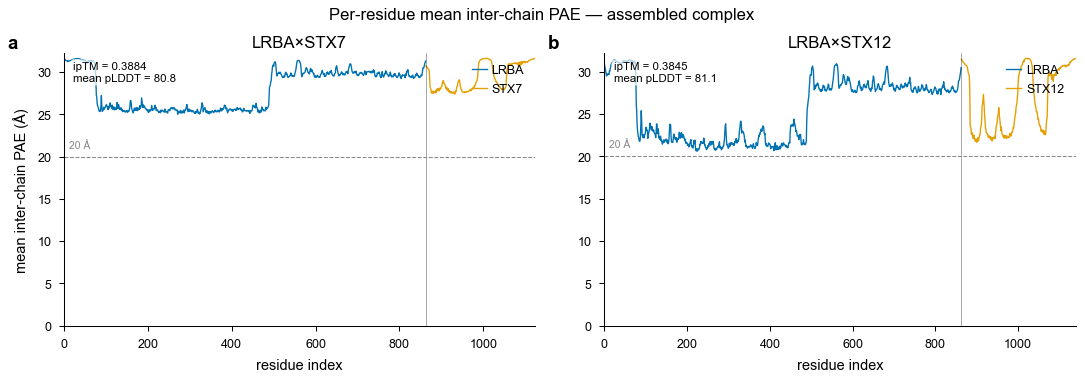

In [15]:
# ── Figure 7: Per-residue mean inter-chain PAE (both pairs side by side) ─────
fig, axes = plt.subplots(1, 2, figsize=(NC2, NC2 * 0.35), constrained_layout=True)

for ax, (pair_name, meta), panel in zip(axes, assembled_pairs.items(), ["a", "b"]):
    pae = meta["pae"]
    tc  = meta["tc"]
    chain_gene = meta["chain_gene"]

    unique_tc = list(dict.fromkeys(c for c in tc if c not in LIGAND_CHAINS))
    x_offset  = 0
    cb_pos    = [0]

    for k, c in enumerate(unique_tc):
        mask_c  = (tc == c)
        inter_c = (tc != c) & np.array([cc not in LIGAND_CHAINS for cc in tc])
        y_vals  = (
            pae[mask_c][:, inter_c].mean(axis=1)
            if inter_c.any() else np.full(mask_c.sum(), np.nan)
        )
        xs = np.arange(x_offset, x_offset + len(y_vals))
        ax.plot(xs, y_vals,
                color=WONG[k % len(WONG)], linewidth=0.65,
                label=chain_gene.get(c, c))
        x_offset += len(y_vals)
        cb_pos.append(x_offset)

    for b in cb_pos[1:-1]:
        ax.axvline(b, color="k", linewidth=0.4, alpha=0.4)

    ax.axhline(20, color="#888888", linestyle="--", linewidth=0.5)
    ax.text(x_offset * 0.01, 20.8, "20 Å", color="#888888", fontsize=5, va="bottom")

    ax.set_xlim(0, x_offset)
    ax.set_ylim(bottom=0)
    ax.set_title(pair_name, pad=3)
    ax.set_ylabel("mean inter-chain PAE (Å)" if ax is axes[0] else "")
    ax.set_xlabel("residue index")
    ax.legend(loc="upper right", handlelength=1.2, handletextpad=0.4)

    iptm_str = f"{meta['iptm']:.4f}" if not np.isnan(meta['iptm']) else "n/a"
    ax.text(0.02, 0.97,
            f"ipTM = {iptm_str}\nmean pLDDT = {meta['mean_plddt']:.1f}",
            transform=ax.transAxes, fontsize=5.5, va="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

    ax.text(-0.12, 1.07, panel, transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

fig.suptitle("Per-residue mean inter-chain PAE — assembled complex", fontsize=8)
save_fig(fig, "inter_chain_pae_per_residue")
plt.show()

**Fig. 7 | Per-residue mean inter-chain PAE for the LRBA–STX7 and LRBA–STX12 complexes.**
For each residue *i*, the mean PAE to all residues of the partner chain is plotted as a function of residue index. The ligand chain is excluded. Blue: LRBA; orange: STX7 or STX12. The dashed grey line marks 20 Å; residues below this threshold contribute most to interface confidence. The ipTM and mean pLDDT (from the assembled complex model) are annotated.